# **Twitter Hate Speech Detection**

# Importing Libraries

In [ ]:
pip install wordcloud lazypredict

In [ ]:
import pandas as pd
from sklearn.utils import resample
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, plot_precision_recall_curve
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from lazypredict.Supervised import LazyClassifier, LazyRegressor
import pickle
import time

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings 
warnings.filterwarnings('ignore')

# Loading Dataset 1

In [ ]:
train1 = pd.read_csv('/kaggle/input/twitter-hate-speech/train_E6oV3lV.csv')
print("Training Set 1 :"% train1.columns, train1.shape)
test1 = pd.read_csv('/kaggle/input/twitter-hate-speech/test_tweets_anuFYb8.csv')
print("Test Set 1 :"% test1.columns, test1.shape)

print('Train Set 1 -----')
print(train1.isnull().sum())
print('Test Set 1 -----')
print(test1.isnull().sum())
train1.head()

# Loading Dataset 2

In [ ]:
df = pd.read_csv('/kaggle/input/cyberbullying-dataset/toxicity_parsed_dataset.csv')
df.head()

# Selecting only useful columns of Dataset2

In [ ]:
df = df[['index','oh_label','Text']]
df.head()

# Renaming the Selected Columns

In [ ]:
# Before renaming the columns
print("\nBefore modifying column names:\n", df.columns)

df.rename(columns = {'index':'id','oh_label':'label','Text':'tweet'}, inplace = True)
  
# After renaming the columns
print("\nAfter modifying first column:\n", df.columns)

# Splitting the Dataset into Train and Test dataset

In [ ]:
train2, test2 = train_test_split(df, test_size=0.3,random_state=10, shuffle=True)

train2 = train2[['id','label','tweet']]
test2 = test2[['id','tweet']]

print("Training Set 2 :"% train2.columns, train2.shape)
print("Test Set 2 :"% test2.columns, test2.shape)
print('Train Set 2 -----')
print(train2.isnull().sum())
print('Test Set 2 -----')
print(test2.isnull().sum())
train2.head()

# Merging Train and Test Datasets from Dataset1 and Dataset2

In [ ]:
# Merging two Train Data Sets
train = pd.concat([train1, train2], ignore_index = True)
train.shape

In [ ]:
train['label'].value_counts()

In [ ]:
# Merging two Test Data Sets
test = pd.concat([test1,test2], ignore_index = True)
test.shape

# Data Analysis and Cleaning

In [ ]:
def  clean_text(df, text_field):
    df[text_field] = df[text_field].str.lower()
    df[text_field] = df[text_field].apply(lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?", "", elem))  
    return df
test_clean = clean_text(test, "tweet")
train_clean = clean_text(train, "tweet")

train_majority = train_clean[train_clean.label==0]
train_minority = train_clean[train_clean.label==1]
train_minority_upsampled = resample(train_minority, 
                                 replace=True,    
                                 n_samples=len(train_majority),   
                                 random_state=123)
train_upsampled = pd.concat([train_minority_upsampled, train_majority])
train_upsampled['label'].value_counts()

In [ ]:
train_upsampled

# Visualizing the Data

In [ ]:
fig, axs = plt.subplots(1,2 , figsize=(16,8))
text_pos = " ".join(train_clean['tweet'][train.label == 0])
text_neg = " ".join(train_clean['tweet'][train.label == 1])
train_cloud_pos = WordCloud(collocations = False, background_color = 'white').generate(text_pos)
train_cloud_neg = WordCloud(collocations = False, background_color = 'black').generate(text_neg)
axs[0].imshow(train_cloud_pos, interpolation='bilinear')
axs[0].axis('off')
axs[0].set_title('Non-Hate Comments')
axs[1].imshow(train_cloud_neg, interpolation='bilinear')
axs[1].axis('off')
axs[1].set_title('Hate Comments')

plt.show()

In [ ]:
plt.figure(figsize=(16,8))
sns.set_style('darkgrid')
sns.histplot(data = train['label'], color='black', legend=True)
sns.histplot(data = train_upsampled['label'], color = 'orange', legend=True)
plt.legend(['Initial_Data', 'Resampled_Data'])
plt.show()

In [ ]:
print('--------------After Upsampling the Minority Class---------------')

fig, axs = plt.subplots(1,2 , figsize=(16,8))
text_pos = " ".join(train_upsampled['tweet'][train.label == 0])
text_neg = " ".join(train_upsampled['tweet'][train.label == 1])
train_cloud_pos = WordCloud(collocations = False, background_color = 'white').generate(text_pos)
train_cloud_neg = WordCloud(collocations = False, background_color = 'black').generate(text_neg)
axs[0].imshow(train_cloud_pos, interpolation='bilinear')
axs[0].axis('off')
axs[0].set_title('Non-Hate Comments')
axs[1].imshow(train_cloud_neg, interpolation='bilinear')
axs[1].axis('off')
axs[1].set_title('Hate Comments')

plt.show()

In [ ]:
dt_trasformed = train_upsampled[['label', 'tweet']]
y = dt_trasformed.iloc[:, :-1].values

In [ ]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
y = np.array(ct.fit_transform(y))

y

In [ ]:
print(y.shape)

In [ ]:
y_df = pd.DataFrame(y)
y_hate = np.array(y_df[0])
y

In [ ]:
cv = CountVectorizer(max_features = 2000)
x = cv.fit_transform(train_upsampled['tweet']).toarray()
x

In [ ]:
x.shape

# Train & Test splitting the Data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y_hate, test_size = 0.30, random_state = 1)

# **Testing With Different Models**
## Gaussian Naive Bayes, Decision Tree, K Nearest Neighbors, Random Forest, SVM

## Naive Bayes

In [ ]:
# Using Naive Bayes Classifier

classifier_np = GaussianNB()

# Start timer
start_time = time.time()

classifier_np.fit(x_train, y_train)

# End timer
end_time = time.time()

In [ ]:
# Calculate training time
training_time = end_time - start_time

print(f"Training time of Naive Bayes: {training_time:.6f} seconds")

In [ ]:
# save the model to disk
filename = 'twitter_with_two_dataset_model_GaussianNB.sav'
pickle.dump(classifier_np, open(filename, 'wb'))

## Decision Tree

In [ ]:
# Using Decision Tree

classifier_dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)

# Start timer
start_time = time.time()

classifier_dt.fit(x_train, y_train)

# End timer
end_time = time.time()

In [ ]:
# Calculate training time
training_time = end_time - start_time

print(f"Training time of Decision Tree: {training_time:.6f} seconds")

In [ ]:
# save the model to disk
filename = 'twitter_with_two_dataset_model_Decision_Tree.sav'
pickle.dump(classifier_dt, open(filename, 'wb'))

## K-Nearest Neighbors

In [ ]:
# Using KNN

classifier_knn = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)

# Start timer
start_time = time.time()

classifier_knn.fit(x_train, y_train)

# End timer
end_time = time.time()

In [ ]:
# Calculate training time
training_time = end_time - start_time

print(f"Training time of KNN: {training_time:.6f} seconds")

In [ ]:
# save the model to disk
filename = 'twitter_with_two_dataset_model_KNN.sav'
pickle.dump(classifier_knn, open(filename, 'wb'))

## Logistic Regression

In [ ]:
# Using Logistic Regression

classifier_lr = LogisticRegression(random_state = 0)

# Start timer
start_time = time.time()

classifier_lr.fit(x_train, y_train)

# End timer
end_time = time.time()

In [ ]:
# Calculate training time
training_time = end_time - start_time

print(f"Training time of Logistic Regression: {training_time:.6f} seconds")

In [ ]:
# save the model to disk
filename = 'twitter_with_two_dataset_model_Logistic_Regression.sav'
pickle.dump(classifier_lr, open(filename, 'wb'))

## Random Forest

In [ ]:
# Using Random Forest

classifier_rf = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)

# Start timer
start_time = time.time()

classifier_rf.fit(x_train, y_train)

# End timer
end_time = time.time()

In [ ]:
# Calculate training time
training_time = end_time - start_time

print(f"Training time of Random Forest: {training_time:.6f} seconds")

In [ ]:
# save the model to disk
filename = 'twitter_with_two_dataset_model_Random_Forest.sav'
pickle.dump(classifier_rf, open(filename, 'wb'))

## SVM

In [ ]:
# Using Support Vector Machine

'''classifier_svm = svm.SVC(kernel = 'linear')

# Start timer
start_time = time.time()

classifier_svm.fit(x_train, y_train)

# End timer
end_time = time.time()'''

In [ ]:
'''# Calculate training time
training_time = end_time - start_time

print(f"Training time of SVM: {training_time:.6f} seconds")'''

In [ ]:
# save the model to disk
'''filename = 'twitter_with_two_dataset_model_SVM.sav'
pickle.dump(classifier_svm, open(filename, 'wb'))'''

# Confusion Matrix for Different Models

## Naive Bayes

In [ ]:
#Naive Bayes
y_pred_np = classifier_np.predict(x_test)
cm = confusion_matrix(y_test, y_pred_np)
print(cm)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_np, labels = [1,0]), display_labels = [True, False])
cm_display.plot()
plt.show()

In [ ]:
yhat_np = classifier_np.predict_proba(x_test)
print('y_hat_shape for Naive Bayes: ',yhat_np.shape)
yhat_np = yhat_np[:, 1]
fpr_np, tpr_np, _ = metrics.roc_curve(y_test, yhat_np)
auc_np = round(metrics.roc_auc_score(y_test, yhat_np), 4)

## Decision Tree

In [ ]:
#Decision Tree
y_pred_dt = classifier_dt.predict(x_test)
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_dt, labels = [1,0]), display_labels = [True, False])
cm_display.plot()
plt.show()

In [ ]:
yhat_dt = classifier_dt.predict_proba(x_test)
print('y_hat_shape for Decision Tree: ',yhat_dt.shape)
yhat_dt = yhat_dt[:, 1]
fpr_dt, tpr_dt, _ = metrics.roc_curve(y_test, yhat_dt)
auc_dt = round(metrics.roc_auc_score(y_test, yhat_dt), 4)

## K-Nearest Neighbors

In [ ]:
#KNN
y_pred_knn = classifier_knn.predict(x_test)
cm = confusion_matrix(y_test, y_pred_knn)
print(cm)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_knn, labels = [1,0]), display_labels = [True, False])
cm_display.plot()
plt.show()

In [ ]:
yhat_knn = classifier_knn.predict_proba(x_test)
print('y_hat_shape for KNN: ',yhat_knn.shape)
yhat_knn = yhat_knn[:, 1]
fpr_knn, tpr_knn, _ = metrics.roc_curve(y_test, yhat_knn)
auc_knn = round(metrics.roc_auc_score(y_test, yhat_knn), 4)

## Logistic Regression

In [ ]:
#Logistic Regression
y_pred_lr=classifier_lr.predict(x_test)
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_lr, labels = [1,0]), display_labels = [True, False])
cm_display.plot()
plt.show()

In [ ]:
yhat_lr = classifier_lr.predict_proba(x_test)
print('y_hat_shape for Logistic Regression: ',yhat_lr.shape)
yhat_lr = yhat_lr[:, 1]
fpr_lr, tpr_lr, _ = metrics.roc_curve(y_test, yhat_lr)
auc_lr = round(metrics.roc_auc_score(y_test, yhat_lr), 4)

## Random Forest

In [ ]:
#Random Forest
y_pred_rf = classifier_rf.predict(x_test)
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_rf, labels = [1,0]), display_labels = [True, False])
cm_display.plot()
plt.show()

In [ ]:
yhat_rf = classifier_rf.predict_proba(x_test)
print('y_hat_shape for Random Forest: ',yhat_rf.shape)
yhat_rf = yhat_rf[:, 1]
fpr_rf, tpr_rf, _ = metrics.roc_curve(y_test, yhat_rf)
auc_rf = round(metrics.roc_auc_score(y_test, yhat_rf), 4)

## Support Vector Machine

In [ ]:
#SVM
'''y_pred_svm = classifier_svm.predict(x_test)
cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_svm, labels = [1,0]), display_labels = [True, False])
cm_display.plot()
plt.show()'''

In [ ]:
'''yhat_svm = classifier_svm.predict_proba(x_test)
print('y_hat_shape for SVM: ',yhat_svm.shape)
yhat_svm = yhat_svm[:, 1]
fpr_svm, tpr_svm, _ = metrics.roc_curve(y_test, yhat_svm)
auc_svm = round(metrics.roc_auc_score(y_test, yhat_svm), 4)'''

# Generating the Accuracy & F1 Score

In [ ]:
rf_score = accuracy_score(y_test, y_pred_rf)
knn_score = accuracy_score(y_test, y_pred_knn)
#svm_score = accuracy_score(y_test, y_pred_svm)
lr_score = accuracy_score(y_test, y_pred_lr)
dt_score = accuracy_score(y_test, y_pred_dt)
np_score = accuracy_score(y_test, y_pred_np)

print ('--' * 20)
print('Random Forest Accuracy: ', str(rf_score))
print('F1 score: ', f1_score(y_test, y_pred_rf, labels = [1,0]))
print ('--' * 20)
print ('')
print ('--' * 20)
print('K-Nearest Neighbors Accuracy: ', str(knn_score))
print('F1 score: ', f1_score(y_test, y_pred_knn, labels = [1,0]))
print ('--' * 20)
print ('')
'''print ('--' * 20)
print('Support Vector Machine Accuracy: ', str(svm_score))
print('F1 score: ', f1_score(y_test, y_pred_svm, labels = [1,0]))
print ('--' * 20)
print ('')'''
print ('--' * 20)
print('Logistic Regression Accuracy: ',str(lr_score))
print('F1 score: ', f1_score(y_test, y_pred_lr, labels = [1,0]))
print ('--' * 20)
print ('')
print ('--' * 20)
print('Decision Tree Accuracy: ', str(dt_score))
print('F1 score: ', f1_score(y_test, y_pred_dt, labels = [1,0]))
print ('--' * 20)
print ('')
print ('--' * 20)
print('Naive Bayes Accuracy: ', str(np_score))
print('F1 score: ', f1_score(y_test, y_pred_np, labels = [1,0]))
print ('--' * 20)
print ('')

# Generating the performance metrics of several other models using Lazy Predict

### Classification models

In [ ]:
'''clf = LazyClassifier(verbose=0,predictions=True)
lazymodels,predictions = clf.fit(x_train, x_test, y_train, y_test)
lazymodels'''

### Regresson Models

In [ ]:
'''reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
reggmodels, predictions = reg.fit(x_train, x_test, y_train, y_test)
reggmodels'''

# Precision-Recall Curve & ROC Curve generation for the trained models

In [ ]:
from sklearn.metrics import plot_precision_recall_curve

plot_precision_recall_curve(classifier_np, x_test, y_test, ax = plt.gca(),name = "Naive Bayes")

plot_precision_recall_curve(classifier_dt, x_test, y_test, ax = plt.gca(),name = "Decision Tree")

plot_precision_recall_curve(classifier_knn, x_test, y_test, ax = plt.gca(),name = "K-Nearest Neighbors")

plot_precision_recall_curve(classifier_lr, x_test, y_test, ax = plt.gca(),name = "Logistic Regression")

plot_precision_recall_curve(classifier_rf, x_test, y_test, ax = plt.gca(),name = "Random Forest")

plt.title('Precision-Recall curve')

In [ ]:
plt.plot(fpr_np,tpr_np,label="Naive Bayes, AUC="+str(auc_np))
plt.plot(fpr_dt,tpr_dt,label="Decision Tree, AUC="+str(auc_dt))
plt.plot(fpr_knn,tpr_knn,label="K-Nearest Neighbors, AUC="+str(auc_knn))
plt.plot(fpr_lr,tpr_lr,label="Logistic Regression, AUC="+str(auc_lr))
plt.plot(fpr_rf,tpr_rf,label="Random Forest, AUC="+str(auc_rf))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve')

#add legend
plt.legend()

<br>
<p style="text-align:center; font-weight:800; font-size:18px"><em>Thank you! For viewing this Notebook, do upvote if you like it and please feel free to provide feedback.</em>
<p style="text-align:center"><img src="https://cdn.pixabay.com/animation/2023/03/21/22/04/22-04-05-16_512.gif" width="480" height="200"></p>

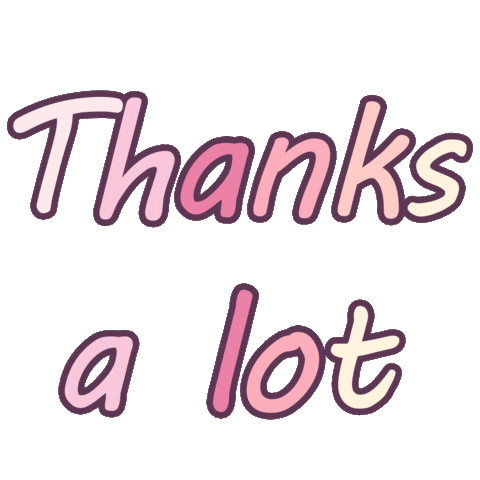